#  Shallow tunnel surrogate modeling with FEniCSx and JAX+Equinox

:::{important}
In this tutorial, the objectives are to develop a machine learning surrogate model for simulating a tunnel excavated at shallow depth. For this purpose, a synthetic dataset will first be generated using FEniCSx and a dense neural network will be trained using JAX+Equinox.
:::

# Installation

The link to install FeniCSx is:
[https://fenicsproject.org/download/](https://fenicsproject.org/download/)

It is recommended to create a virtual environment to install all libraries and packages related to FEniCSx, Gmsh and JAX. In the base environment, write:

```bash
conda create -n fenicsx-env
conda activate fenicsx-env
conda install -c conda-forge fenics-dolfinx mpich pyvista python-gmsh tqdm ipywidgets
```
In this project, we will use JAX, Optax and Equinox libraries for training multi-layer perceptrons (MLPs):

```bash
conda install -c conda-forge jax optax equinox
```

It is recommended to install jupyter lab within your fenicsx-env environment:
```bash
conda activate fenicsx-env 
conda install -c conda-forge jupyterlab
```

:::{caution}
If jupyter lab is already installed in another virtural env, you may need to register the fenicsx-env as a kernel:
```bash
conda deactivate
conda activate your-jupyter-virtual-env
conda install ipykernel
python -m ipykernel install --user --name fenicsx-env --display-name "Python (fenicsx)"
```
:::

You should now be able to see "Python (fenicsx)" kernel when opening jupyter lab.

Launch jupyter lab:

```bash
conda activate fenicsx-env 
jupyter lab
```
or
```bash
conda activate your-jupyter-virtual-env
jupyter lab
```

Let's get started!

# Problem description

The problem under consideration is a circular shallow tunnel excavated in an elastic ground. The domain is modeled as a rectangle with length $L = 40~\mathrm{m}$ and height $H = 30~\mathrm{m}$, and the tunnel has a radius $R = 1~\mathrm{m}$ located at a depth $d = 4~\mathrm{m}$ from the surface. Boundary conditions are applied by fixing vertical displacements at the bottom of the domain and horizontal displacements on the left and right boundaries. 

<div style="text-align: center;">
  <img src="Images/simple_utilidor.jpg" width="65%">
  <figcaption><em>Figure 1: Circular shallow tunnel</em></figcaption>
</div>

It is assumed that the ground is initially subjected to an in-situ stress state, with the vertical stress generated by gravity and the horizontal stress taken equal to the vertical stress. To incorporate this initial stress state, **eigenstrains** can be introduced into the formulation. As a result, the computed displacements correspond only to the **effects of the tunnel excavation**, disregarding the initial compression of the ground. 

## Consitutive behavior

Using Lamé's coefficients $\lambda$ and $\mu$, the Hooke's law reads as:

$$
\boldsymbol{\sigma}(\boldsymbol{u}) = \lambda \mathrm{tr} \left(\boldsymbol{\varepsilon}(\boldsymbol{u}) - \boldsymbol{\varepsilon}^{*}) \right) \boldsymbol{I} + 2\mu \left( \boldsymbol{\varepsilon}(\boldsymbol{u}) - \boldsymbol{\varepsilon}^{*} \right) 
$$

where $\boldsymbol{u}$ denotes the displacement field (the solution of the boundary-value problem), $\boldsymbol{\sigma}(\boldsymbol{u})$ corresponds to the Cauchy stress tensor, $\boldsymbol{\varepsilon}(\boldsymbol{u})$ corresponds to the total deformations and $\boldsymbol{\varepsilon}^{*}$ are eigenstrains obtained in the presence of an in-situ stress state. 

Assuming small strains:

$$ 
\boldsymbol{\varepsilon}(\boldsymbol{u}) = \dfrac{1}{2} \left[\boldsymbol{\nabla}\boldsymbol{u} + (\boldsymbol{\nabla}\boldsymbol{u})^T)   \right] 
$$

the Hooke's law can further be expressed as:

$$
\boldsymbol{\sigma}(\boldsymbol{u}) = \lambda \left[\nabla \cdot \boldsymbol{u} - \mathrm{tr}(\boldsymbol{\varepsilon}^*) \right]\boldsymbol{I} + \mu \left[ \nabla \boldsymbol{u} + \left(\nabla \boldsymbol{u}\right)^T\right]
$$

Noting $\mathbb{S}$ the compliance tensor and $\boldsymbol{\sigma}^0$ the in-situ stress state ruling in the massif, eigenstrains are computed as follows:

$$
\boldsymbol{\varepsilon}^{*} = \mathbb{S}:\boldsymbol{\sigma}^0
$$

where:

$$
\boldsymbol{\sigma}^0 =
\begin{bmatrix}
\sigma_h & 0 \\
0 & \sigma_v
\end{bmatrix}
$$

with $\sigma_v =\sigma_h = \gamma y$ which denote respectively the vertical and horizontal stress states and where $\gamma$ is the volumetric weight of the ground.


In the presence of body forces (here gravity), the equilibrium equations that one aims to solve is:

$$
-\nabla\boldsymbol{\sigma}(\boldsymbol{u}) = \boldsymbol{f}
$$


## Variational formulation

In FEniCSx, one has to use the variational formulation to solve the problem. 

:::{seealso}
We refer here to @dokken_fenicsx_tutorial for a general introduction about the variational formulation of linear elasticity in the FEniCSx context as well as to @bleyer2024comet for numerical tours in FEniCSx. 
:::
<!-- [https://jsdokken.com/dolfinx-tutorial/chapter2/linearelasticity.html](https://jsdokken.com/dolfinx-tutorial/chapter2/linearelasticity.html) and to @bleyer2024comet

[https://bleyerj.github.io/comet-fenicsx/intro/linear_elasticity/linear_elasticity.html](https://doi.org/10.5281/zenodo.10470942) for greater details.  -->


In this problem, the variational form reads as:

Find $\boldsymbol{u} \in V$, such that:

$$
\int_\Omega \boldsymbol{\sigma}(\boldsymbol{u}) : \boldsymbol{\nabla}\boldsymbol{v} \, d\Omega =
\int_\Omega \mathbf{f} \cdot \mathbf{v} \, d\Omega
+
\int_{\partial \Omega_T} \mathbf{T} \cdot \mathbf{v} \, ds,
\quad
\forall \mathbf{v} \in \mathbf{\hat V}
\tag{1}
$$

where $\boldsymbol{u}$ is the unknown displacement (trial function) in the space of admissible displacements $\mathbf{V}$ and $\boldsymbol{v}$ corresponds to the test functions living in the space of admissible perturbations $\mathbf{\hat V}$. $\mathbf{T}$ corresponds to the surface traction (for instance surface load due to traffic or the presence of buildings). 

The left side of the equation is known as the bilinear form and often noted $a(\boldsymbol{u}, \boldsymbol{v})$ and the right term as the linear form noted $L(\boldsymbol{v})$ so that the variational form reads as:

$$
a(\boldsymbol{u}, \boldsymbol{v}) = L(\boldsymbol{v})
\quad
\forall \mathbf{v} \in \mathbf{\hat V}
$$

# FEniCSx Implementation

## Mesh

It is possible to define the mesh directly in python by importing and using the `gmsh` library. 

Once created, the mesh is converted into a `dolfinx` mesh, and the physical markers (subdomains and boundaries) are extracted so we can use them in finite element simulations. This is done by importing and using `MPI` from `mpi4py` and `gmsh` from `dolfinx.io`.

In [1]:
import gmsh
from mpi4py import MPI
from dolfinx.io import gmsh as gmshio

def mesh(L, H, d, R, mesh_name):

    mesh_comm = MPI.COMM_WORLD
    model_rank = 0
    gdim = 2
    fdim = 1

    if mesh_comm.rank == model_rank:

        # Initialize GMSH
        gmsh.initialize()
        gmsh.model.add("utilidor")
        
        # Mesh size
        mesh_size_far = 2.0     # Far away from tunnel wall
        mesh_size_near = 0.2    # Close to the tunnel wall
        
        # Rectangular box
        p1 = gmsh.model.geo.addPoint(-L/2, -H, 0, mesh_size_far)
        p2 = gmsh.model.geo.addPoint(L/2, -H, 0, mesh_size_far)
        p3 = gmsh.model.geo.addPoint(L/2, 0, 0, mesh_size_far)
        p4 = gmsh.model.geo.addPoint(-L/2, 0, 0, mesh_size_far)
        
        l1 = gmsh.model.geo.addLine(p1, p2)
        l2 = gmsh.model.geo.addLine(p2, p3)
        l3 = gmsh.model.geo.addLine(p3, p4)
        l4 = gmsh.model.geo.addLine(p4, p1)
        
        outer_box = gmsh.model.geo.addCurveLoop([l1, l2, l3, l4])
        
        # Tunnel cavity
        center = gmsh.model.geo.addPoint(0, -d, 0, mesh_size_near)
        p_tunnel_1 = gmsh.model.geo.addPoint(R, -d, 0, mesh_size_near)
        p_tunnel_2 = gmsh.model.geo.addPoint(0, R-d, 0, mesh_size_near)
        p_tunnel_3 = gmsh.model.geo.addPoint( -R, -d, 0, mesh_size_near)
        p_tunnel_4 = gmsh.model.geo.addPoint(0, -R-d, 0, mesh_size_near)
        
        arc1 = gmsh.model.geo.addCircleArc(p_tunnel_1, center, p_tunnel_2)
        arc2 = gmsh.model.geo.addCircleArc(p_tunnel_2, center, p_tunnel_3)
        arc3 = gmsh.model.geo.addCircleArc(p_tunnel_3, center, p_tunnel_4)
        arc4 = gmsh.model.geo.addCircleArc(p_tunnel_4, center, p_tunnel_1)
        
        tunnel_wall = gmsh.model.geo.addCurveLoop([arc1, arc2, arc3, arc4])
        
        # Surface = domain - tunnel
        surface = gmsh.model.geo.addPlaneSurface([outer_box, tunnel_wall])
        
        gmsh.model.geo.synchronize()
        
        # Define physical groups for further boundary conditions
        gmsh.model.addPhysicalGroup(fdim, [l1], 1, name="bottom")
        gmsh.model.addPhysicalGroup(fdim, [l2], 2, name="right")
        gmsh.model.addPhysicalGroup(fdim, [l3], 3, name="top")
        gmsh.model.addPhysicalGroup(fdim, [l4], 4, name="left")
        gmsh.model.addPhysicalGroup(fdim, [arc1, arc2, arc3, arc4], 5, name="tunnel_wall")
        gmsh.model.addPhysicalGroup(gdim, [surface], 6, name="domain")
        
        # 2D mesh
        gmsh.model.mesh.generate(gdim)
        
        # Save gmsh file to visualize in Gmsh for instance
        gmsh.write(f"{mesh_name}.msh")

        # Import in dolfinx
        mesh_data = gmshio.model_to_mesh(gmsh.model, mesh_comm, model_rank, gdim=gdim)
        domain = mesh_data.mesh
        facet_tags = mesh_data.facet_tags
        
        # Terminates Gmsh API session
        gmsh.finalize()
    
        print(f"Number of cells: {domain.topology.index_map(gdim).size_global}")

    return domain, gdim, fdim, facet_tags

Finally, we would like to visualize the mesh. This is done by importing the `pyvista` library and using the `plot` function from `dolfinx`.

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Circle)
Info    : [ 70%] Meshing curve 6 (Circle)
Info    : [ 80%] Meshing curve 7 (Circle)
Info    : [ 90%] Meshing curve 8 (Circle)
Info    : Done meshing 1D (Wall 0.000575375s, CPU 0.000704s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0139109s, CPU 0.019015s)
Info    : 1035 nodes 2077 elements
Info    : Writing 'simple_utilidor.msh'...
Info    : Done writing 'simple_utilidor.msh'
Number of cells: 1934


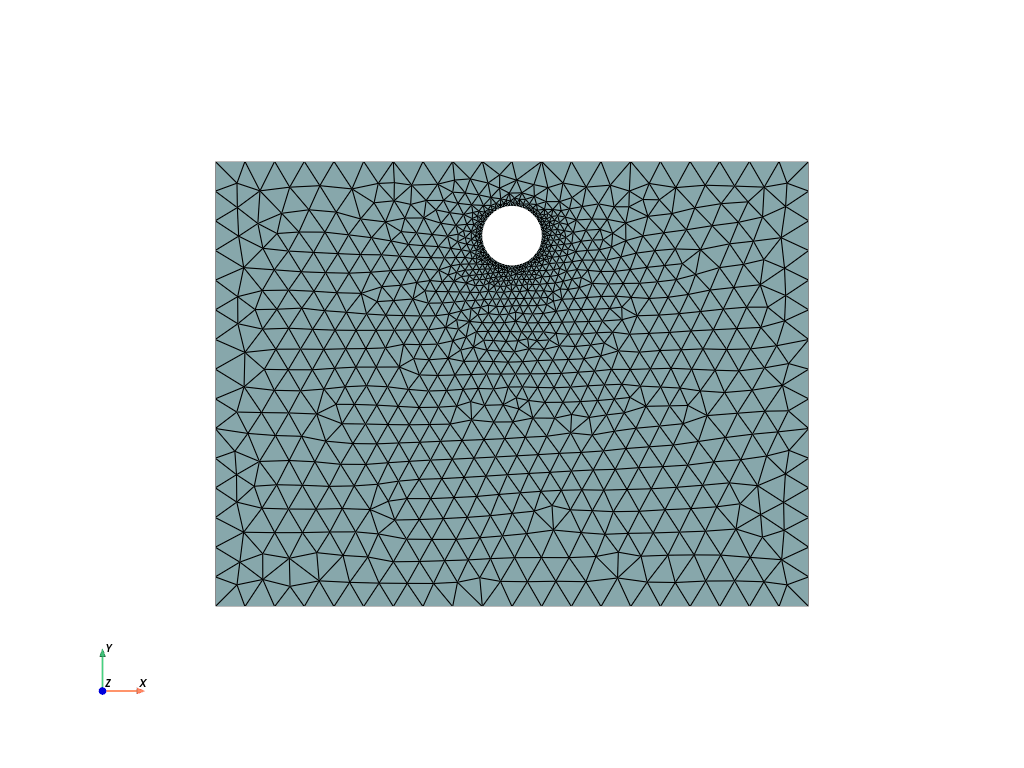

In [2]:
import pyvista
from dolfinx import plot

# Geometrical parameters
R = 2
d = 5  
L = 40.0      
H = 30.0      

mesh_name = "simple_utilidor"
domain, gdim, fdim, facet_tags = mesh(L, H, d, R, mesh_name)

# Visualization
pyvista.set_jupyter_backend("static")
topology, cell_types, geometry = plot.vtk_mesh(domain, gdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

# Create plotter and pyvista grid
p = pyvista.Plotter()
p.add_mesh(grid, show_edges=True)
p.view_xy()
p.show_axes()
p.show()
p.close()

## Solving the problem 
Now, we aim to solve the boundary-value problem using the finite element solver FEniCSx. Here, we define the material constants and apply an in-situ stress state.

In [3]:
from dolfinx import fem
import dolfinx.fem.petsc
import numpy as np

def eigenstrains(E, nu, gamma, domain, gdim):
    ## Eigenstrains section
    # Create a tensor to store the eigenstrain for each cell in the mesh
    # The shape is (num_cells_local, gdim, gdim): for each cell, a gdim x gdim tensor is assigned (since we are in 2D gdim = 2)
    num_cells_local = domain.topology.index_map(gdim).size_local
    eigenstrain_tensor = np.zeros((num_cells_local, gdim, gdim))
    
    # Compute the coordinates of the cell centroids.
    coords = dolfinx.mesh.compute_midpoints(domain, gdim, np.arange(num_cells_local))
    y = coords[:, 1]  
    
    # Define the in-situ stress based on gravity
    sigma_v = -gamma * y  
    sigma_h = sigma_v     
    
    # Compute eigenstrains under the plane-strain assumption 
    factor = (1 + nu.value) / E.value
    eps_xx_star = factor * ((1 - nu.value) * sigma_h - nu.value * sigma_v)  
    eps_yy_star = factor * ((1 - nu.value) * sigma_v - nu.value * sigma_h)  
    
    # Assign the computed eigenstrain components to the strain tensor for each cell
    eigenstrain_tensor[:, 0, 0] = eps_xx_star  
    eigenstrain_tensor[:, 1, 1] = eps_yy_star  
    
    # Define a function space for the eigenstrain field
    # "DG" (Discontinuous Galerkin) of order 0 is chosen because eigenstrains may be discontinuous across elements
    V_strain = fem.functionspace(domain, ("DG", 0, (gdim, gdim)))
    
    # Create a function in this space to represent the eigenstrain tensor field
    epsilon_star = fem.Function(V_strain, name="epsilon_star")
    
    # Assign values from a the precomputed eigenstrain tensor to the function
    # The tensor is reshaped into a 1D array to match the PETSc vector layout of the function
    epsilon_star.x.petsc_vec[:] = eigenstrain_tensor.reshape(-1,)

    return epsilon_star

# Material elastic parameter
E = fem.Constant(domain, 15000e6)
nu = fem.Constant(domain, 0.3)
gamma = 25e3 # N/m^3

epsilon_star = eigenstrains(E, nu, gamma, domain, gdim)

We now formulate the variational problem. This is done in FEniCSx by importing the `UFL` (Unified Form Language) package that allows us to formalize the symbolic expressions of the constitutive behavior. 

:::{tip}
In FEniCSx, one can use the UFL functions `ufl.lhs` and `ufl.rhs` to extract the bilinear and respectivelely the linear terms (separating the terms that depend on both the trial and test functions on the one side and the terms that only depend on the test function on the other).
:::


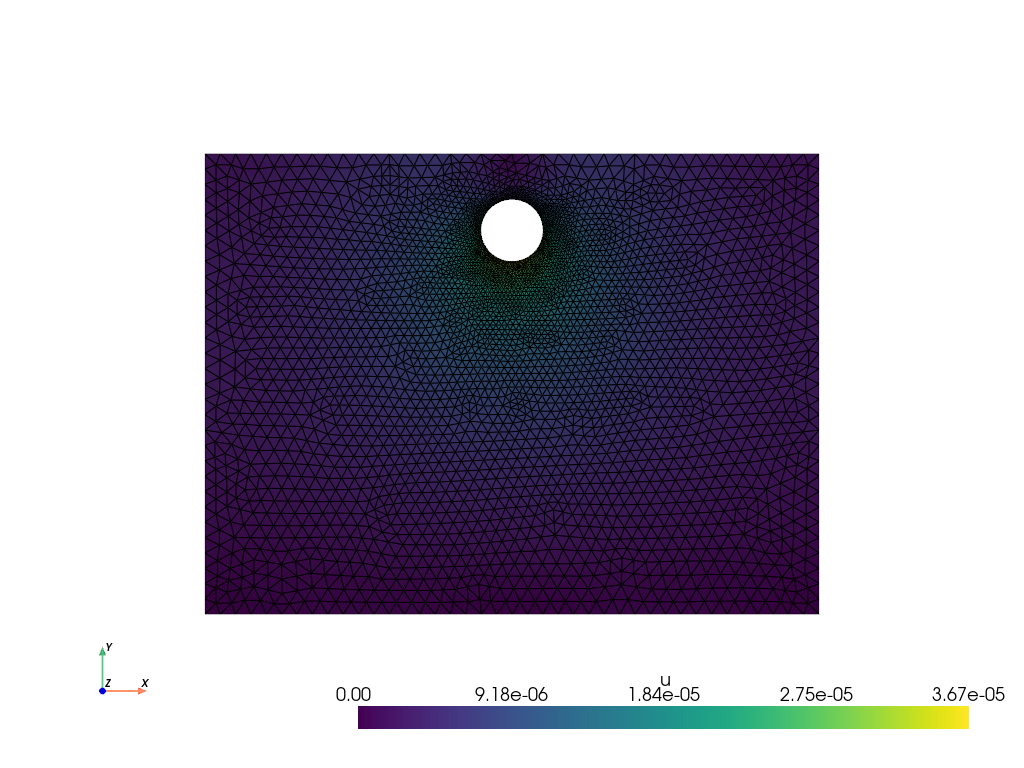

In [4]:
import ufl
from ufl import sym, grad, Identity, tr, inner, Measure, TestFunction, TrialFunction
from dolfinx import fem, io, default_scalar_type

# Small strains
def epsilon(v):
    return sym(grad(v))

# Constitutive bahavior
def sigma(v, E, nu, epsilon_star):
    lmbda = E * nu / (1 + nu) / (1 - 2 * nu)
    mu = E / 2 / (1 + nu)
    epsilon_tot = epsilon(v) - epsilon_star
    return lmbda * tr(epsilon_tot) * Identity(gdim) + 2 * mu * (epsilon_tot)

def solve(E, nu, epsilon_star, domain, facet_tags, T_top, gdim, fdim):
    
    # Creation of a function space for both the Trial and Test functions. 
    # Note that the same space is used for both. 
    # "P", 2 : quadratic Lagrange elements (degree 2)
    # (gdim,) : 2 components for u_x and u_y displacements
    V = fem.functionspace(domain, ("P", 2, (gdim,)))
    u = TrialFunction(V) 
    v = TestFunction(V) 
    u_sol = fem.Function(V, name="Displacement")
    
    # Left part of the variational formulation
    # Define domain integration measure (by default ufl.dx would work)
    dx = ufl.Measure("dx", domain=domain)
    Wint = ufl.inner(sigma(u, E, nu, epsilon_star), epsilon(v)) * dx
    
    # Extract the bilinear term 
    aM = ufl.lhs(Wint)
    
    # A Measure is created to allow integrating over facets (boundary surfaces) 
    ds = Measure("ds", domain=domain, subdomain_data=facet_tags)
    
    # Volumetric body force 
    f = fem.Constant(domain, default_scalar_type((0, -gamma)))
    
    # Linear term (right part of the variational form)
    LM = (ufl.rhs(Wint) + 
          ufl.dot(f, v) * ufl.dx + 
          ufl.dot(T_top, v) * ds(3) 
         )
    
    # Dirichlet - Fixed vertical displacement at the bottom (uy) and horizontal left/right (ux)
    bottom_facets = facet_tags.find(1)
    right_facets = facet_tags.find(2)
    left_facets = facet_tags.find(4)
    
    # Extract function spaces for each displacement component separately
    # .collapse() gives the underlying scalar function space needed for applying Dirichlet BCs.
    V_ux, _ = V.sub(0).collapse()
    V_uy, _ = V.sub(1).collapse()
    
    # Locate the degrees of freedom (DoFs) associated with each boundary
    bottom_dofs = fem.locate_dofs_topological((V.sub(1), V_uy), fdim, bottom_facets)
    left_dofs = fem.locate_dofs_topological((V.sub(0), V_ux), fdim, left_facets)
    right_dofs = fem.locate_dofs_topological((V.sub(0), V_ux), fdim, right_facets)
    
    # Functions defining the Dirichlet values (zero displacement by default)
    ux0 = fem.Function(V_ux)
    uy0 = fem.Function(V_uy)
    
    # Define the actual Dirichlet boundary conditions
    bcs = [
        fem.dirichletbc(ux0, left_dofs, V.sub(0)),
        fem.dirichletbc(ux0, right_dofs, V.sub(0)),
        fem.dirichletbc(uy0, bottom_dofs, V.sub(1))
    ]
    
    # Wrap-up the problem
    problem = fem.petsc.LinearProblem(
        aM, 
        LM, 
        u=u_sol, 
        bcs=bcs, 
        petsc_options={"ksp_type":"preonly", "pc_type":"lu"},
        petsc_options_prefix="linear_elasticity_utilidor"
    )
    problem.solve()

    return u_sol, V
    

# Traction-free on top - To be modified if necessary
T_top = fem.Constant(domain, default_scalar_type((0,0)))

# Solve the problem  
u_sol, V = solve(E, nu, epsilon_star, domain, facet_tags, T_top, gdim, fdim)

# Create pvd file for using in Paraview
vtk = io.VTKFile(domain.comm, "Utilidor.pvd", "w")
vtk.write_function(u_sol)
vtk.close()

# Visualization
p = pyvista.Plotter()
topology, cell_types, geometry = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)

grid["u"] = np.c_[u_sol.x.array.reshape((-1,2)), np.zeros(geometry.shape[0])]
warped = grid.warp_by_vector("u", factor=0)
p.add_mesh(warped, show_edges=True)
p.view_xy()          
p.enable_parallel_projection()  
p.show_axes()
p.show()

## Von Mises stress

We can now use the obtained solution to compute the stress field - here von Mises, defined as:

$$
\sigma_\mathrm{vm} = \sqrt{\frac{3}{2} \, \mathbf{s} : \mathbf{s}}
$$

where the deviatoric stress tensor is

$$
\mathbf{s} = \boldsymbol{\sigma} - \frac{1}{3} \, \mathrm{tr}(\boldsymbol{\sigma}) \, \mathbf{I}.
$$

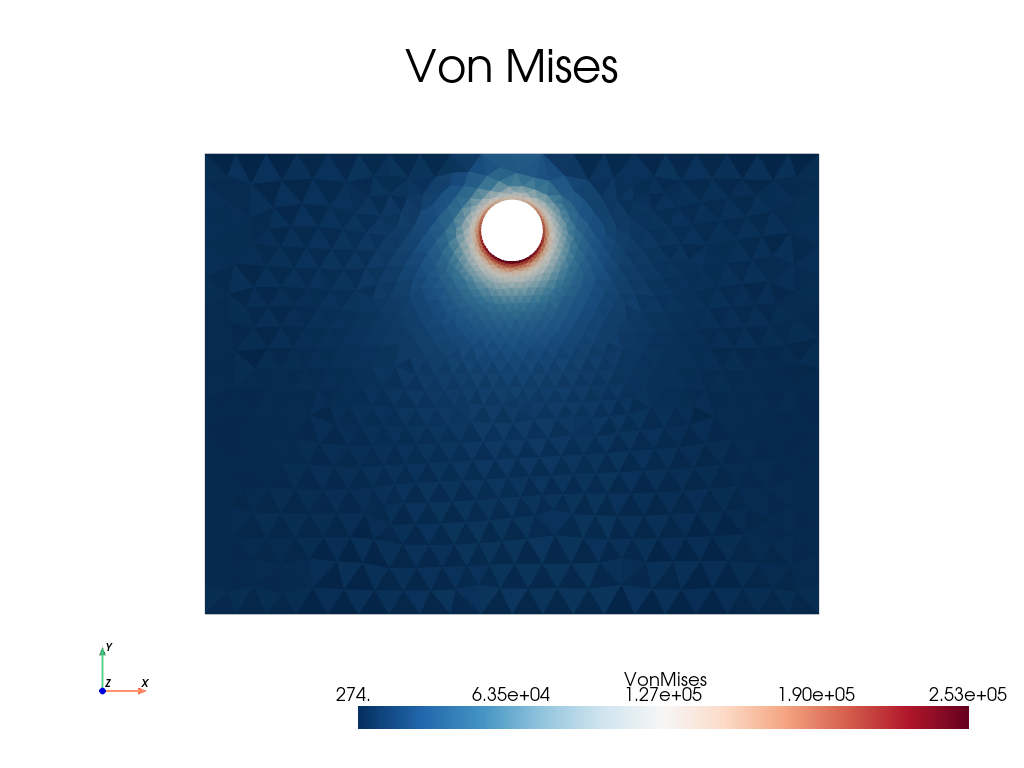

In [5]:
# Stress computations
def stress_VM(u):
    lmbda = E * nu / (1 + nu) / (1 - 2 * nu)
    mu = E / 2 / (1 + nu)
    s = lmbda * tr(epsilon(u)) * Identity(gdim) + 2 * mu * (epsilon(u))
    s_dev = s - (tr(s) / gdim) * Identity(gdim)  
    von_Mises = ufl.sqrt(3.0 / 2 * ufl.inner(s_dev, s_dev))
    return von_Mises

von_Mises = stress_VM(u_sol)

V_von_mises = fem.functionspace(domain, ("DG", 0))
stress_expr = fem.Expression(von_Mises, V_von_mises.element.interpolation_points)
stresses = fem.Function(V_von_mises)
stresses.interpolate(stress_expr)

topology_vm, cell_types_vm, geometry_vm = plot.vtk_mesh(V_von_mises.mesh)

grid_vm = pyvista.UnstructuredGrid(topology_vm, cell_types_vm, geometry_vm)

grid_vm.cell_data["VonMises"] = stresses.x.array.real
grid_vm.set_active_scalars("VonMises")

p = pyvista.Plotter()
p.add_mesh(grid_vm, cmap="RdBu_r", show_edges=False)
p.add_title("Von Mises")
p.view_xy()
p.enable_parallel_projection()
p.show_axes()
if not pyvista.OFF_SCREEN:
    p.show()
else:
    p.screenshot(f"VonMises.png")

## Stress xx, yy and xy 

The stress tensor returned by `sigma()` is a symbolic UFL expression. It defines how stresses are computed from the displacement field but does not yet contain numerical values. To evaluate this expression, FEniCSx first wraps it in a `fem.Expression`, which prepares the UFL expression for numerical evaluation at a set of interpolation points on the mesh. The resulting expression can then be interpolated into a `fem.Function` defined on a finite element space (for example DG0). The `interpolate()` operation evaluates the expression at the element interpolation points and stores the resulting numerical values in the function, which can then be visualized or exported.

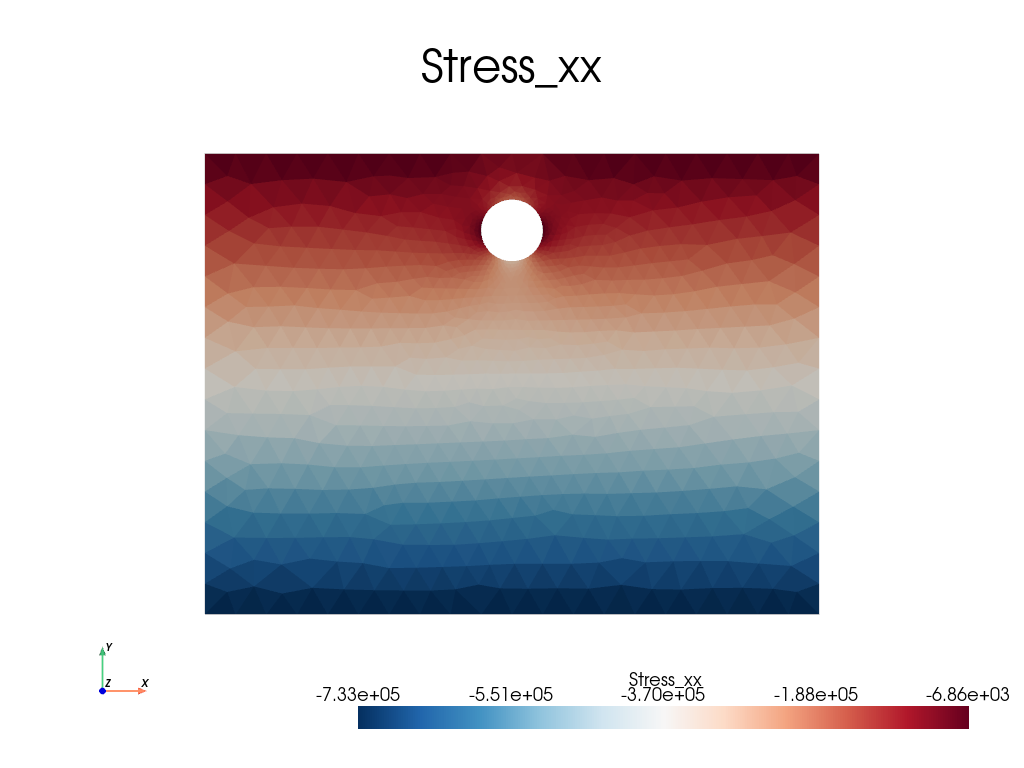

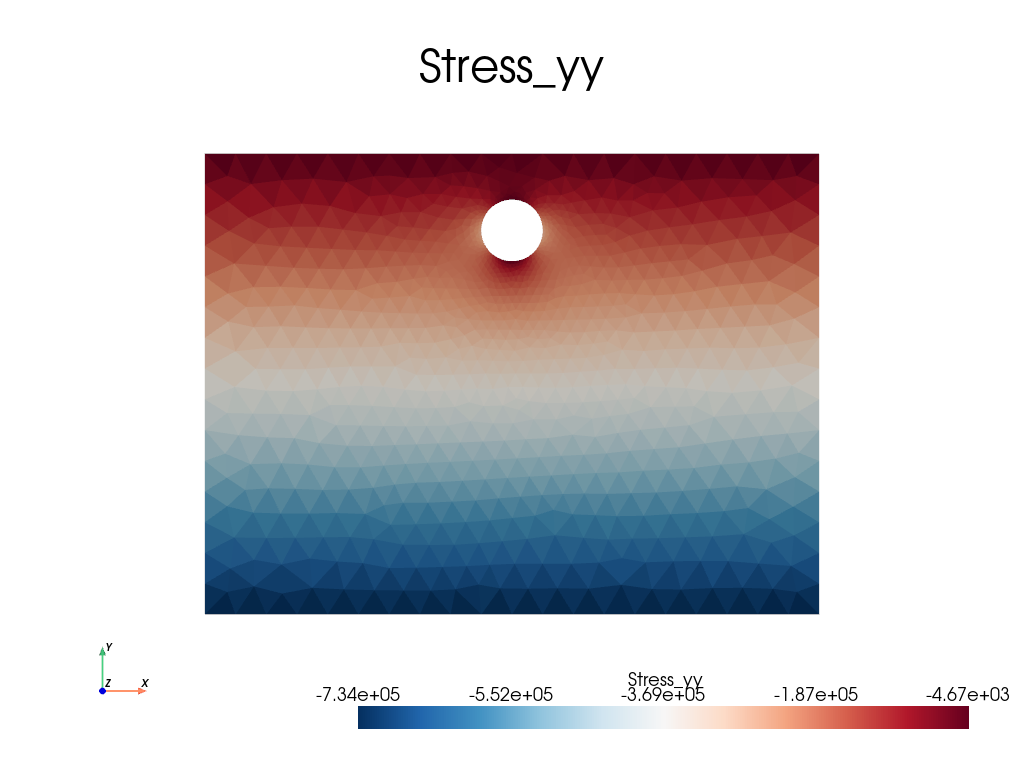

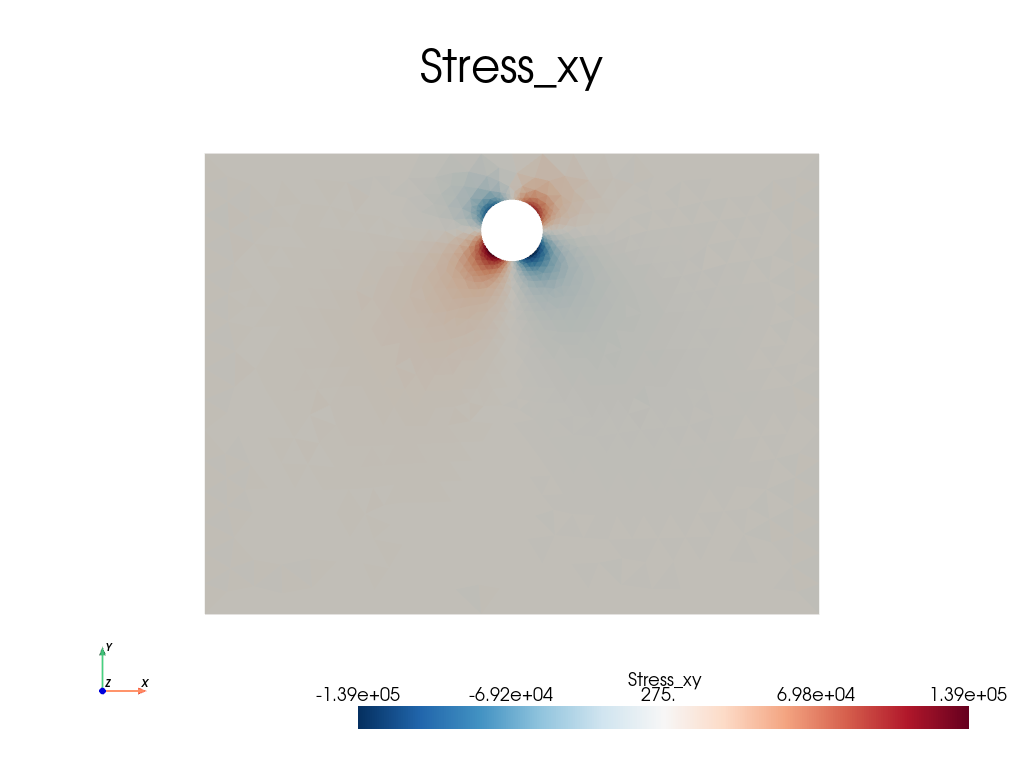

In [6]:
# Compute the stress (UFL)
stresses = sigma(u_sol, E, nu, epsilon_star)

# Define the solution space (constant functions per element)
V_stress = fem.functionspace(domain, ("DG", 0))

# Create FEniCSx expression for each component of the stress tensor
sigma_xx_expr = fem.Expression(stresses[0, 0], V_stress.element.interpolation_points)
sigma_yy_expr = fem.Expression(stresses[1, 1], V_stress.element.interpolation_points)
sigma_xy_expr = fem.Expression(stresses[0, 1], V_stress.element.interpolation_points)

# Create fem function for further interpolation of the stress expressions
sigma_xx = fem.Function(V_stress, name="sigma_xx")
sigma_yy = fem.Function(V_stress, name="sigma_yy")
sigma_xy = fem.Function(V_stress, name="sigma_xy")
sigma_xx.interpolate(sigma_xx_expr)
sigma_yy.interpolate(sigma_yy_expr)
sigma_xy.interpolate(sigma_xy_expr)

# Build the grid on V_stress (DG 0)
topology_s, cell_types_s, geometry_s = plot.vtk_mesh(V_stress.mesh)

grid_stress = pyvista.UnstructuredGrid(topology_s, cell_types_s, geometry_s)

for field, name in [
    (sigma_xx, "Stress_xx"),
    (sigma_yy, "Stress_yy"),
    (sigma_xy, "Stress_xy"),
]:
    grid_stress.cell_data[name] = field.x.array.real
    grid_stress.set_active_scalars(name)

    p = pyvista.Plotter()
    p.add_mesh(grid_stress, cmap="RdBu_r", show_edges=False)
    p.add_title(name)
    p.view_xy()
    p.enable_parallel_projection()
    p.show_axes()
    if not pyvista.OFF_SCREEN:
        p.show()
    else:
        p.screenshot(f"{name}.png")

# Machine learning surrogate model

## Objectives

So far, the problem has been solved considering a single specific case, i.e. for fixed material parameters, geometry and boundary conditions (BCs). To simulate a different case, one need to repeat the process again: mesh, define material constants and BCs and run the simulation. However, computing several simulations may be time consuming. 

As an alternative, it is proposed in this part to develop a surrogate model that maps the simulation input parameters to the displacement field, which is supposed to faster computations at inference time. For this purpose, a multi-layer perceptron is implemented.

:::{seealso}
For a detailed explanation and an implementation from scratch of a multi-layer perceptron, check the [Multi-layer perceptron from scratch](http://localhost:3000/mlp-from-scratch) tutorial!
:::

:::{seealso}
The reader is referred to the work of @tristani_phd for a complete description of the pipeline used to create machine learning surrogate models in the context of tunneling, from the generation of synthetic datasets to the training and evaluation of model performance. dditional developments can be found in @tristani2025data, which focuses on predicting ground–structure interaction in deep tunnels.
:::

## Dataset

The first step to build a machine learning surrogate model is to create a dataset. This dataset is used to tune the parameters of the model in order to accurately fit the data (training stage) and to assess its performance (testing stage). 

In this tutorial, we will only generate a dataset for different Young's moduli ($E$) to compute the displacement at the crown and at the bottom of the tunnel:

$$E \xrightarrow{\text{ML model}} \boldsymbol{u}$$

For further study, you may find relvant to add the weight of the ground as well as the depth / geometry / BCs!

### Synthetic data generation

For generating the dataset, a function that extract the relevant displacement field can first be defined.

In [7]:
def extract_tunnel_crown_invert(u_sol, V, facet_tags, fdim, d, R):

    # Collapsed spaces
    V_ux, _ = V.sub(0).collapse()
    V_uy, _ = V.sub(1).collapse()

    # Interpolation 
    ux_func = fem.Function(V_ux)
    uy_func = fem.Function(V_uy)
    ux_func.interpolate(u_sol.sub(0))
    uy_func.interpolate(u_sol.sub(1))

    # Dofs at the tunnel wall
    facets = facet_tags.find(5)

    # locate_dofs_topological 
    local_ux = fem.locate_dofs_topological(V_ux, fdim, facets)
    local_uy = fem.locate_dofs_topological(V_uy, fdim, facets)

    coords  = V_ux.tabulate_dof_coordinates()[local_ux]  # (n, 3)
    ux_vals = ux_func.x.array[local_ux]
    uy_vals = uy_func.x.array[local_uy]

    # Relevant coordinates
    targets = {
        "crown":  np.array([0.0, -d + R]),
        "invert": np.array([0.0, -d - R]),
    }

    results = {}

    for label, target in targets.items():
        dist = np.sqrt(
            (coords[:, 0] - target[0])**2 +
            (coords[:, 1] - target[1])**2
        )
        idx = np.argmin(dist)

        results[label] = {
            "coords": coords[idx, :2],
            "ux":     ux_vals[idx],
            "uy":     uy_vals[idx],
        }

    ux_bottom = results["invert"]["ux"]
    uy_bottom = results["invert"]["uy"]
    ux_top = results["crown"]["ux"]
    uy_top = results["crown"]["uy"]

    u_field = np.array([ux_bottom, uy_bottom, ux_top, uy_top])

    return u_field

To generate samples, one can define define a sampling strategy for the input variables (here $E$). In this tutorial, we will consider `random uniform sampling` between predefined ranges.

:::{hint}
The main advantage of this method is that data can progressively be added to one another. However, the drawback is that the input space may not be explored efficiently. Other methods exist, such as Latin hypercube sampling but the size of
the grid must be defined initially @mckay2000comparison.
:::

For each sample generated, the following code solve the problem and store the relevant displacement field in a tensor named `u_computed`. 

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 20%] Meshing curve 2 (Line)
Info    : [ 30%] Meshing curve 3 (Line)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 60%] Meshing curve 5 (Circle)
Info    : [ 70%] Meshing curve 6 (Circle)
Info    : [ 80%] Meshing curve 7 (Circle)
Info    : [ 90%] Meshing curve 8 (Circle)
Info    : Done meshing 1D (Wall 0.000211083s, CPU 0.000412s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.0114069s, CPU 0.018207s)
Info    : 996 nodes 1999 elements
Info    : Writing 'simple_utilidor.msh'...
Info    : Done writing 'simple_utilidor.msh'
Number of cells: 1856


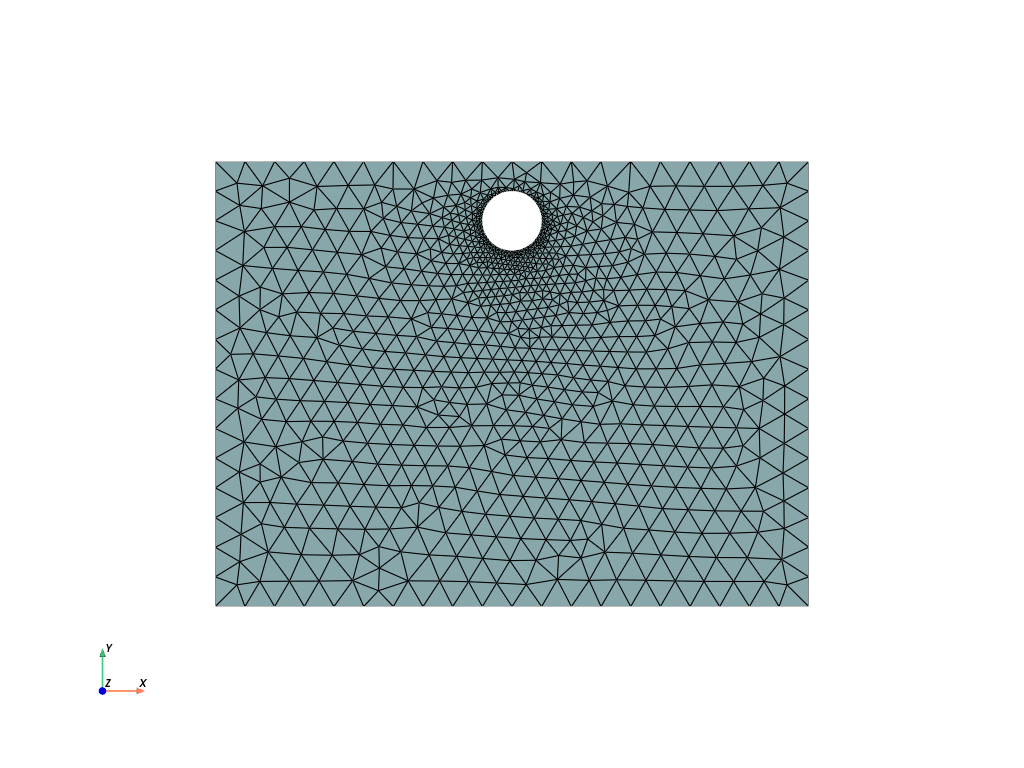

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:15<00:00, 31.75it/s]


In [8]:
from tqdm import tqdm

# Mesh
L = 40.0      
H = 30.0      
d = 4
R = 2.0    

mesh_name = "simple_utilidor"
domain, gdim, fdim, facet_tags = mesh(L, H, d, R, mesh_name)

pyvista.set_jupyter_backend("static")
topology, cell_types, geometry = plot.vtk_mesh(domain, gdim)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
p = pyvista.Plotter()
p.add_mesh(grid, show_edges=True)
p.view_xy()
p.show_axes()
p.show()

# Dataset
gamma = 25e3 # N/m^3
E_range = [1000e6, 40000e6]
nu = fem.Constant(domain, 0.3)
T_top = fem.Constant(domain, default_scalar_type((0,0)))

# Define the number of samples beforehand
n_inputs = 1
N_samples = 500
params_sampled = np.zeros(shape=(N_samples, n_inputs))

# Define a numpy array that will further contain the computed displacement field
n_outputs = 4
u_computed = np.zeros(shape=(N_samples, n_outputs))

# Main loop to generate the dataset
np.random.seed(42)
for i in tqdm(range(N_samples)):

    # Sample Young's modulus E
    E_i_numpy = np.random.uniform(E_range[0], E_range[1])
    params_sampled[i] = np.array([E_i_numpy])
    E_i = fem.Constant(domain, E_i_numpy)

    # Solve the problem  
    epsilon_star_i = eigenstrains(E_i, nu, gamma, domain, gdim)
    u_sol_i, V_i = solve(E_i, nu, epsilon_star_i, domain, facet_tags, T_top, gdim, fdim)

    # Extract and store relevant displacement field
    u_top_bottom = extract_tunnel_crown_invert(u_sol_i, V_i, facet_tags, fdim, d, R)
    u_computed[i] = u_top_bottom

### Scaling

A dataset is classically decomposed into a training set and a test set (80%-20%). A validation set can be separated from the training set again in proportion 80%-20%. 

The training set's purpose is to tune the parameters of the model.
The validation set is used to limit overfitting and or used to tune the hyperparameters of the model (e.g. number of hidden layers / number of neurons / learning rates). The test set is used at the final stage to evaluate the performance of the model. It remains unused during training time. 

It is often good practice to scale the data to improve convergence speed and numerical stability during optimization. Inputs with very different ranges (such as $E$ and $\nu$) can cause the loss landscape to be poorly conditioned, leading to uneven gradients and slower training. 

:::{hint}
Scaling can be achieved using min-max normalization, which maps values to a fixed range such as $[0,1]$ or $[−1,1]$, or standardization, which transforms data to have zero mean and unit variance. Output scaling may also be beneficial, particularly when the target values span several orders of magnitude.
:::

In [11]:
class min_max_scaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        X = np.array(X, dtype=float)
        self.min_ = X.min(axis=0)
        self.max_ = X.max(axis=0)

    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_)
        
    def inverse_transform(self, X_scaled):
        return X_scaled * (self.max_ - self.min_) + self.min_

    def fit_transform(self, X):
        self.fit(X)
        X_scaled = self.transform(X)
        return X_scaled

def train_test_split(X, y, test_size=0.2, random_state=42):
    X = np.array(X)
    y = np.array(y)

    indices = np.arange(len(X))

    # Shuffle
    np.random.seed(random_state)
    np.random.shuffle(indices)

    # Get indices
    test_length = int(test_size * len(X))
    test_indices = indices[:test_length]
    train_indices = indices[test_length:]

    # Split
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

# Split full train - test
X_train_full, X_test, y_train_full, y_test = train_test_split(params_sampled, u_computed)

# Split train - validation
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full)

# Scale inputs
input_scaler = min_max_scaler()
X_train_scaled = input_scaler.fit_transform(X_train)
X_val_scaled = input_scaler.transform(X_val)
X_test_scaled = input_scaler.transform(X_test)

print(f"Input train shape: {X_train_scaled.shape}")
print(f"Input validation shape: {X_val_scaled.shape}")
print(f"Input test shape: {X_test_scaled.shape}")

# Scale outputs
output_scaler = min_max_scaler()
y_train_scaled = output_scaler.fit_transform(y_train)
y_val_scaled = output_scaler.transform(y_val)
y_test_scaled = output_scaler.transform(y_test)

print(f"Output train shape: {y_train_scaled.shape}")
print(f"Output validation shape: {y_val_scaled.shape}")
print(f"Output test shape: {y_test_scaled.shape}")

Input train shape: (320, 1)
Input validation shape: (80, 1)
Input test shape: (100, 1)
Output train shape: (320, 4)
Output validation shape: (80, 4)
Output test shape: (100, 4)


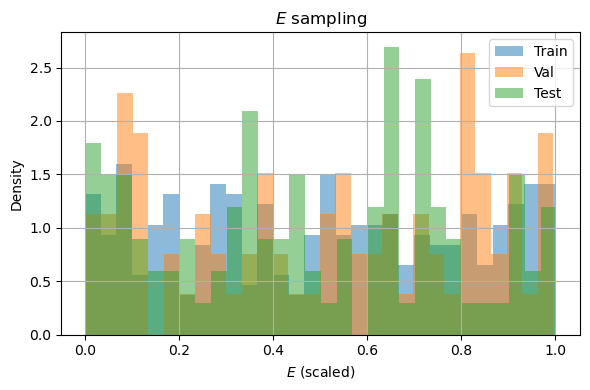

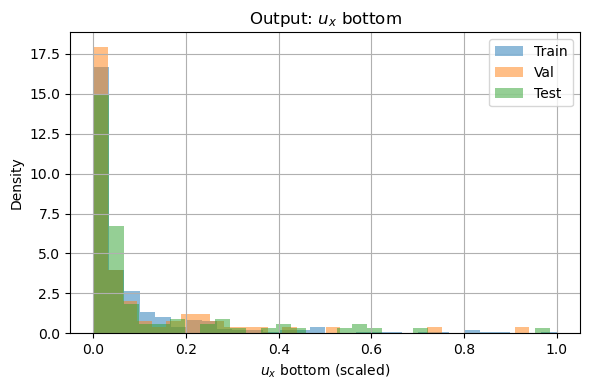

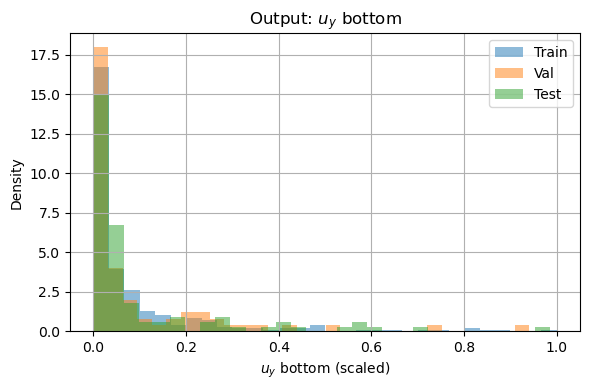

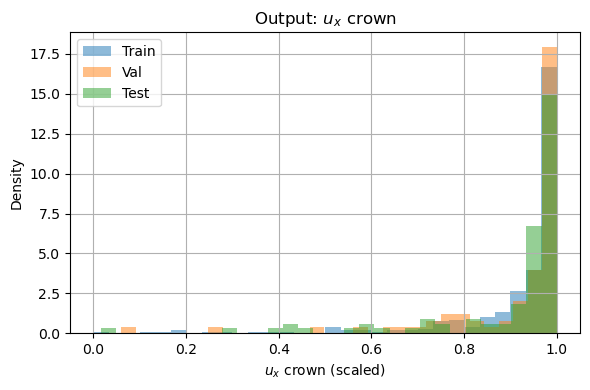

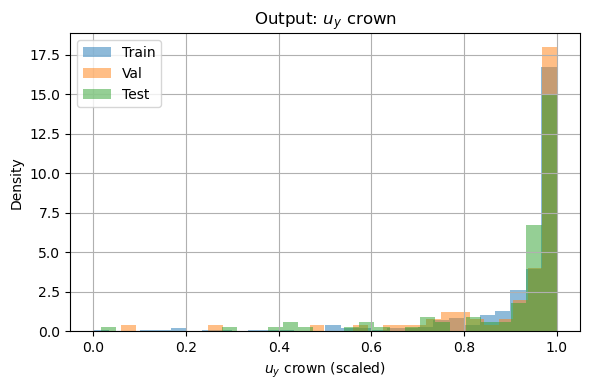

In [12]:
import matplotlib.pyplot as plt

def plot_histograms(arrays_dict, bins=30, title="Histogram", xlabel="Value"):

    fig, ax = plt.subplots(figsize=(6, 4))
    for label, X in arrays_dict.items():
        X = np.array(X).flatten()
        ax.hist(X, bins=bins, density=True, alpha=0.5, label=label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    plt.close()

# Input
plot_histograms(
    {"Train": X_train_scaled, "Val": X_val_scaled, "Test": X_test_scaled},
    title=r"$E$ sampling",
    xlabel=r"$E$ (scaled)"
)

# Outputs
output_labels = [r"$u_x$ bottom", r"$u_y$ bottom", r"$u_x$ crown", r"$u_y$ crown"]
for i, label in enumerate(output_labels):
    plot_histograms(
        {
            "Train": y_train_scaled[:, i],
            "Val":   y_val_scaled[:, i],
            "Test":  y_test_scaled[:, i],
        },
        title=f"Output: {label}",
        xlabel=f"{label} (scaled)"
    )

## Surrogate model

In this section, we will use the `Equinox` library to define the model and `Optax` library for optimising model parameters.  

### Model

In [13]:
import jax
import equinox as eqx

class MLP(eqx.Module):
    layers:list
    activation: callable = jax.nn.relu
    
    def __init__(self, in_size, out_size, hidden_sizes, key):
        keys = jax.random.split(key, len(hidden_sizes) + 1)
        self.layers = []
        
        last_size = in_size
        for h, k in zip(hidden_sizes, keys[:-1]):
            self.layers.append(eqx.nn.Linear(last_size, h, key=k))
            last_size = h
        # Output layer
        output_layer = eqx.nn.Linear(last_size, out_size, key=keys[-1])
        self.layers.append(output_layer)

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

### Training

In [55]:
from jax import vmap
import jax.numpy as jnp
from equinox import filter_jit, filter_value_and_grad, apply_updates, is_array

def get_batch(X, y, key, batch_size=32):
    n = X.shape[0]
    indices = jax.random.permutation(key, n)
    for i in range(0, n, batch_size):
        batch_indices = indices[i:i+batch_size]  
        yield X[batch_indices], y[batch_indices]

def loss_fn(model, X, y_true):
    y_pred = vmap(model)(X)
    return jnp.mean((y_true - y_pred)**2)

@filter_jit
def update_state(model, opt_state, X, y_true):
    loss, grads = filter_value_and_grad(loss_fn)(model, X, y_true)
    updates, opt_state = optimizer.update(grads, opt_state, params=model)
    new_model = apply_updates(model, updates)
    return new_model, opt_state, loss

def train(model, opt_state, X_train_scaled, X_val_scaled, y_train, y_val, n_epochs, key):
    train_loss_history, val_loss_history = [], []
    for epoch in range(n_epochs):
        key, subkey = jax.random.split(key)
        batch_losses = []
        for (X_train_scaled_batch, y_train_scaled_batch) in get_batch(X_train_scaled, y_train_scaled, subkey):
            model, opt_state, batch_loss = update_state(model, opt_state, X_train_scaled_batch, y_train_scaled_batch)
            batch_losses.append(batch_loss)
        train_loss = jnp.mean(jnp.array(batch_losses))
        train_loss_history.append(train_loss)
        val_loss = loss_fn(model, X_val_scaled, y_val)
        val_loss_history.append(val_loss)
        if (epoch+1)%100 == 0:
            print(f"Epoch: {epoch+1}: Train loss: {train_loss:.2e}; Val loss: {val_loss:.2e}")
    return model, train_loss_history, val_loss_history

:::{note}
The optimizer Adam is used in this study.
:::

Training can start!

MLP(
  layers=[
    Linear(
      weight=f32[10,1],
      bias=f32[10],
      in_features=1,
      out_features=10,
      use_bias=True
    ),
    Linear(
      weight=f32[10,10],
      bias=f32[10],
      in_features=10,
      out_features=10,
      use_bias=True
    ),
    Linear(
      weight=f32[4,10],
      bias=f32[4],
      in_features=10,
      out_features=4,
      use_bias=True
    )
  ]
)
Epoch: 100: Train loss: 9.39e-03; Val loss: 9.41e-03


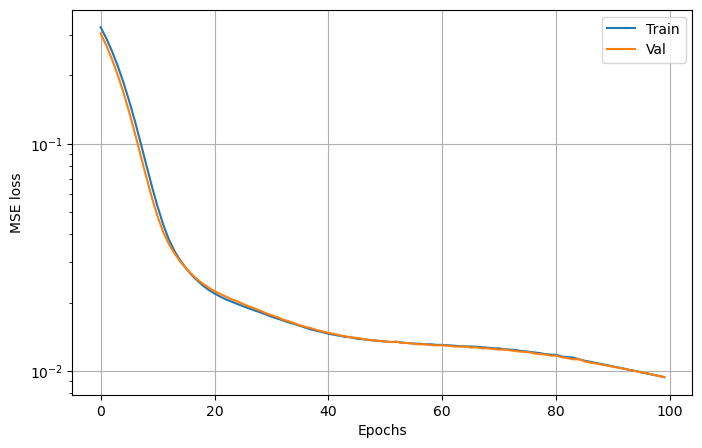

In [60]:
from optax import adam

# Initialize model
key = jax.random.PRNGKey(42)
model = MLP(n_inputs, n_outputs, [10, 10], key)
print(model)

# Initialize optimizer
optimizer = adam(1e-3)
params = eqx.filter(model, is_array) # Filter only array-like parameters
opt_state = optimizer.init(params)

# Training
n_epochs = 100
model, train_loss_history, val_loss_history = train(
                                                    model, 
                                                    opt_state, 
                                                    X_train_scaled, 
                                                    X_val_scaled,
                                                    y_train_scaled, 
                                                    y_val_scaled, 
                                                    n_epochs,
                                                    key
                                                )   

plt.figure(figsize=(8,5))
plt.semilogy(train_loss_history, label="Train")
plt.semilogy(val_loss_history, label="Val")
plt.xlabel("Epochs")
plt.ylabel("MSE loss")
plt.legend()
plt.grid()
plt.show()

In [37]:
float(loss_fn(model, X_val_scaled, y_val_scaled))

0.009412980638444424

### Predictions

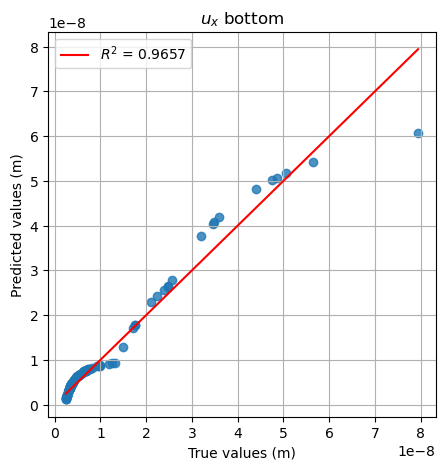

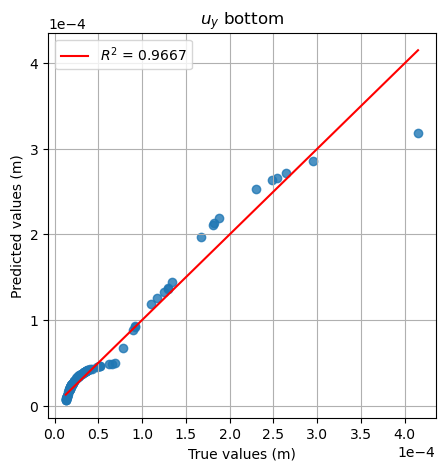

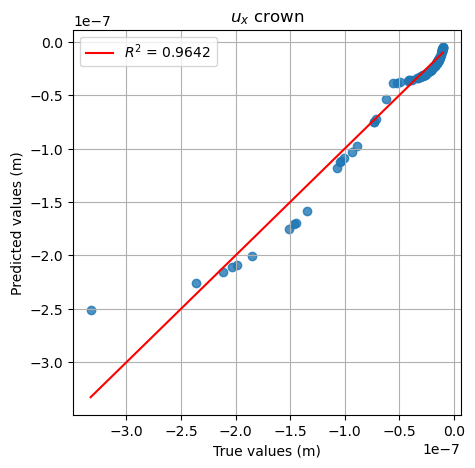

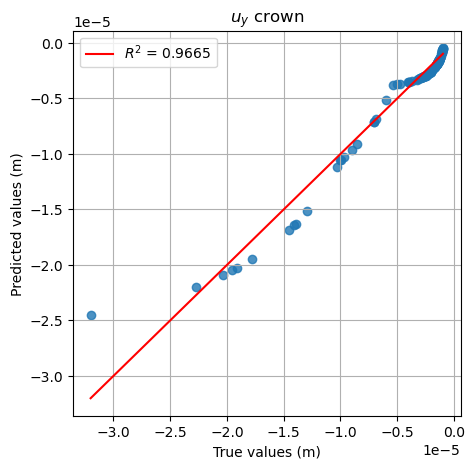

In [25]:
from matplotlib.ticker import ScalarFormatter

def r2_score(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def plot_predictions(y_true, y_preds, labels):
    for j, label in enumerate(labels):
        r2 = r2_score(y_true[:, j], y_preds[:, j])
        vmin = float(y_true[:, j].min())
        vmax = float(y_true[:, j].max())

        fig, ax = plt.subplots(figsize=(5, 5))

        ax.scatter(y_true[:, j], y_preds[:, j], alpha=0.8)
        ax.plot([vmin, vmax], [vmin, vmax], color='red', linestyle='-', label=f"$R^2$ = {r2:.4f}")

        ax.set_xlabel("True values (m)")
        ax.set_ylabel("Predicted values (m)")
        ax.set_title(f"{label}")

        ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))

        ax.legend()
        ax.grid()

        plt.show()

# Test set
y_preds_scaled = vmap(model)(X_test_scaled)
y_preds_unscaled = output_scaler.inverse_transform(y_preds_scaled)
plot_predictions(y_test, y_preds_unscaled, output_labels)

In [65]:
from itertools import product

def grid_search_CV(params_dict, X_train_full, y_train_full, n_cv, key, n_inputs, n_outputs):

    # Create CV folds
    folds = np.array_split(np.arange(len(X_train_full)), n_cv)

    # Generate all hyperparameter combinations
    keys_list = list(params_dict.keys())
    values_list = list(params_dict.values())
    combinations = list(product(*values_list))

    results = []

    for combo in tqdm(combinations):

        param = dict(zip(keys_list, combo))

        hidden_sizes = [param["width"]] * param["hidden_layers"]
        learning_rate = param["learning_rate"]
        n_epochs = param["epochs"]

        val_losses = []

        # Cross-validation loop
        for fold in range(n_cv):

            val_idx = folds[fold]
            train_idx = np.concatenate([folds[i] for i in range(n_cv) if i != fold])

            X_tr, y_tr = X_train_full[train_idx], y_train_full[train_idx]
            X_v,  y_v = X_train_full[val_idx], y_train_full[val_idx]

            # Fit scalers inside each fold (avoid leakage)
            input_scaler = min_max_scaler()
            output_scaler = min_max_scaler()

            X_tr_s = input_scaler.fit_transform(X_tr)
            X_v_s = input_scaler.transform(X_v)

            y_tr_s = output_scaler.fit_transform(y_tr)
            y_v_s = output_scaler.transform(y_v)

            # Initialize model
            key, subkey = jax.random.split(key)
            model = MLP(n_inputs, n_outputs, hidden_sizes, subkey)

            # Optimizer
            optimizer = adam(learning_rate)

            params = eqx.filter(model, eqx.is_array)
            opt_state = optimizer.init(params)

            # Train
            model, _, _ = train(
                                model,
                                opt_state,
                                X_tr_s,
                                X_v_s,
                                y_tr_s,
                                y_v_s,
                                n_epochs,
                                subkey
                            )

            # Validation loss
            val_loss = float(loss_fn(model, X_v_s, y_v_s))
            val_losses.append(val_loss)

        mean_val_loss = np.mean(val_losses)

        results.append({**param, "val_loss": mean_val_loss})

        print(f"{param}: mean val loss: {mean_val_loss:.4e}")

    # Sort by best performance
    results = sorted(results, key=lambda x: x["val_loss"])
    best = results[0]

    print("\nBest hyperparameters:")
    print(best)

    return results, best

params_dict = {
    "hidden_layers": [2],
    "width":         [10],
    "learning_rate": [1e-3],
    "epochs":        [100, 500]
}

results, best_params = grid_search_CV(
    params_dict,
    X_train_full,
    y_train_full,
    n_cv=5,
    key=key,
    n_inputs=n_inputs,
    n_outputs=n_outputs
)

  0%|                                                                                                                                                                                           | 0/2 [00:00<?, ?it/s]

Epoch: 100: Train loss: 2.40e-02; Val loss: 2.92e-02


 50%|█████████████████████████████████████████████████████████████████████████████████████████▌                                                                                         | 1/2 [00:00<00:00,  1.27it/s]

Epoch: 100: Train loss: 2.56e-02; Val loss: 1.70e-02
{'hidden_layers': 2, 'width': 10, 'learning_rate': 0.001, 'epochs': 100}: mean val loss: 2.3129e-02
Epoch: 100: Train loss: 2.66e-02; Val loss: 2.46e-02
Epoch: 200: Train loss: 2.53e-02; Val loss: 2.67e-02
Epoch: 300: Train loss: 2.39e-02; Val loss: 2.68e-02
Epoch: 400: Train loss: 2.41e-02; Val loss: 2.69e-02
Epoch: 500: Train loss: 2.36e-02; Val loss: 2.71e-02
Epoch: 100: Train loss: 2.41e-02; Val loss: 2.20e-02
Epoch: 200: Train loss: 3.13e-02; Val loss: 2.23e-02
Epoch: 300: Train loss: 2.46e-02; Val loss: 2.18e-02
Epoch: 400: Train loss: 3.49e-02; Val loss: 2.19e-02


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:03<00:00,  1.69s/it]

Epoch: 500: Train loss: 2.68e-02; Val loss: 2.19e-02
{'hidden_layers': 2, 'width': 10, 'learning_rate': 0.001, 'epochs': 500}: mean val loss: 2.4497e-02

Best hyperparameters:
{'hidden_layers': 2, 'width': 10, 'learning_rate': 0.001, 'epochs': 100, 'val_loss': np.float64(0.02312856912612915)}


### Exercice - Grid Search with Cross-Validation

The choice of hyperparameters — number of hidden layers, neurons per layer, learning rate, and training epochs — significantly impacts model performance. A standard approach to select the best combination is **grid search with cross-validation**: train and evaluate a model for every combination in a predefined grid, and retain the one with the lowest mean validation loss.

**Implement a `grid_search_CV` function that:**
1. Generates all hyperparameter combinations 
2. For each combination, performs $k$-fold cross-validation — scaling **inside each fold** to avoid data leakage
3. Returns the results sorted by validation loss and the best hyperparameter set

Test your implementation with:
```python
params_dict = {
    "hidden_layers": [1, 2, 3],
    "width":         [10, 20, 30],
    "learning_rate": [1e-2, 1e-3],
    "epochs":        [100, 500, 1000]
}
```

:::{hint}
You may use the `product` function from the itertools library to generate many poss
:::